<a href="https://colab.research.google.com/github/Samir0223/Attention_U_Net-/blob/main/AttentionUNet_ROSE1_Replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention U-Net — ROSE-1 OCTA Vessel Segmentation

Replication of the paper pipeline with:
- **Attention U-Net** (attention gates on every skip connection)
- **Focal-Dice loss** (handles class imbalance: thin vessels ≈ 5–15% of pixels)
- **5-fold cross-validation** on 30 training images
- Full test evaluation: Dice, Jaccard, Sensitivity, Specificity, Hausdorff, AUC

| Setting | Value |
|---|---|
| Model | Attention U-Net |
| Dataset | ROSE-1 (SVC / DVC / SVC_DVC) |
| GT types | `gt`, `thick_gt`, `thin_gt` |
| Loss | Focal-Dice (α=0.25, γ=2) |
| CV | 5-Fold |
| Epochs | 300 |
| LR | 1e-4 (CosineAnnealing) |


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', '-q', 'seaborn'], check=True)

import torch
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {"GPU — " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')


Mounted at /content/drive
PyTorch : 2.10.0+cu128
Device  : GPU — NVIDIA A100-SXM4-40GB


## 2. Configuration

In [2]:
import os

# ── Edit these ─────────────────────────────────────────
BASE_DIR   = '/content/drive/MyDrive/ROSE-1'
CATEGORY   = 'SVC_DVC'   # 'SVC' | 'DVC' | 'SVC_DVC'
GT_TYPE    = 'gt'         # 'gt'  | 'thick_gt' | 'thin_gt'
IMG_SIZE   = 304          # U-Net-friendly; divisible by 2^4=16
BATCH_SIZE = 4
K_FOLDS    = 5
NUM_EPOCHS = 300
LR         = 1e-4
SAVE_DIR   = f'/content/drive/MyDrive/UNet_ROSE1/{CATEGORY}_{GT_TYPE}'
# ───────────────────────────────────────────────────────

os.makedirs(SAVE_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for split in ['train', 'test']:
    for sub in ['img', GT_TYPE]:
        p = os.path.join(BASE_DIR, CATEGORY, split, sub)
        print(f'  {split}/{sub}: {"OK" if os.path.isdir(p) else "MISSING"}')


  train/img: OK
  train/gt: OK
  test/img: OK
  test/gt: OK


## 3. Dataset

In [3]:
import os, random
import numpy as np
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader


class ROSE1Dataset(Dataset):
    """ROSE-1 OCTA dataset loader with optional augmentation."""

    def __init__(self, base_dir, category, split,
                 gt_type='gt', indices=None, augment=False, img_size=304):
        img_dir   = os.path.join(base_dir, category, split, 'img')
        gt_dir    = os.path.join(base_dir, category, split, gt_type)
        all_imgs  = sorted(os.listdir(img_dir))
        all_masks = sorted(os.listdir(gt_dir))

        if indices is not None:
            all_imgs  = [all_imgs[i]  for i in indices]
            all_masks = [all_masks[i] for i in indices]

        self.samples  = [(os.path.join(img_dir, i), os.path.join(gt_dir, m))
                         for i, m in zip(all_imgs, all_masks)]
        self.augment  = augment
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = Image.open(img_path).convert('L')
        mask  = Image.open(mask_path).convert('L')
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask  = mask.resize( (self.img_size, self.img_size), Image.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                image, mask = TF.hflip(image), TF.hflip(mask)
            if random.random() > 0.5:
                image, mask = TF.vflip(image), TF.vflip(mask)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                image, mask = TF.rotate(image, angle), TF.rotate(mask, angle)

        image = TF.to_tensor(image)          # (1, H, W) float32 [0, 1]
        mask  = TF.to_tensor(mask)           # (1, H, W) float32 [0, 1]
        mask  = (mask > 0.5).float()         # binarise
        return image, mask


# Sanity check
ds = ROSE1Dataset(BASE_DIR, CATEGORY, 'train', gt_type=GT_TYPE, img_size=IMG_SIZE)
img, mask = ds[0]
pos_ratio = mask.mean().item()
print(f'Train samples : {len(ds)}')
print(f'Image shape   : {img.shape}  range [{img.min():.2f}, {img.max():.2f}]')
print(f'Mask shape    : {mask.shape} unique {mask.unique().tolist()}')
print(f'Foreground ratio (sample 0): {pos_ratio:.3f}  '
      f'→ imbalance ratio ≈ {(1-pos_ratio)/pos_ratio:.1f}:1 (bg:vessel)')


Train samples : 30
Image shape   : torch.Size([1, 304, 304])  range [0.00, 1.00]
Mask shape    : torch.Size([1, 304, 304]) unique [0.0, 1.0]
Foreground ratio (sample 0): 0.234  → imbalance ratio ≈ 3.3:1 (bg:vessel)


## 4. Attention U-Net

Attention gates suppress irrelevant background skip-connection features,
effectively giving the decoder an imbalance-aware focus on thin vessels.


In [4]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    """Conv → BN → ReLU × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class AttentionBlock(nn.Module):
    """Additive soft-attention gate (Oktay et al., 2018)."""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True),
                                   nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True),
                                   nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True),
                                   nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        alpha = self.psi(self.relu(self.W_g(g) + self.W_x(x)))
        return x * alpha


class UNet(nn.Module):
    """Attention U-Net: encoder depth 64→128→256→512→1024 with 4 attention gates."""

    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        # Decoder + attention gates
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att4 = AttentionBlock(512, 512, 256)
        self.dec4 = DoubleConv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = AttentionBlock(256, 256, 128)
        self.dec3 = DoubleConv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = AttentionBlock(128, 128, 64)
        self.dec2 = DoubleConv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionBlock(64, 64, 32)
        self.dec1 = DoubleConv(128, 64)
        # Output
        self.out  = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        u4 = self.up4(b)
        d4 = self.dec4(torch.cat([u4, self.att4(u4, e4)], dim=1))
        u3 = self.up3(d4)
        d3 = self.dec3(torch.cat([u3, self.att3(u3, e3)], dim=1))
        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, self.att2(u2, e2)], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, self.att1(u1, e1)], dim=1))
        return torch.sigmoid(self.out(d1))


# Quick sanity check
model = UNet().to(device)
total = sum(p.numel() for p in model.parameters())
dummy = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(device)
print(f'Attention U-Net params : {total:,}')
print(f'Output shape           : {model(dummy).shape}')


Attention U-Net params : 31,393,901
Output shape           : torch.Size([1, 1, 304, 304])


## 5. Focal-Dice Loss

Combines **Dice loss** (overlap-based, naturally handles imbalance) with
**Focal loss** (down-weights easy background negatives via $(1-p_t)^\gamma$).
Together they strongly bias learning toward the sparse vessel foreground.


In [5]:
import torch.nn.functional as F


class FocalDiceLoss(nn.Module):
    """
    L = Dice + Focal
      Focal: α * (1 - exp(-BCE))^γ * BCE
      Dice : 1 - (2·TP + ε) / (2·TP + FP + FN + ε)
    """
    def __init__(self, alpha=0.25, gamma=2, smooth=1e-6):
        super().__init__()
        self.alpha  = alpha
        self.gamma  = gamma
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs  = inputs.view(-1)
        targets = targets.view(-1)

        # Dice
        inter     = (inputs * targets).sum()
        dice_loss = 1 - (2. * inter + self.smooth) / \
                        (inputs.sum() + targets.sum() + self.smooth)

        # Focal
        bce        = F.binary_cross_entropy(inputs, targets, reduction='none')
        focal_loss = (self.alpha * (1 - torch.exp(-bce)) ** self.gamma * bce).mean()

        return dice_loss + focal_loss


# Quick loss sanity check
_loss_fn = FocalDiceLoss()
_p = torch.rand(2, 1, 64, 64)
_t = (torch.rand(2, 1, 64, 64) > 0.85).float()  # ~15% foreground
print(f'FocalDiceLoss on random imbalanced batch: {_loss_fn(_p, _t):.4f}')


FocalDiceLoss on random imbalanced batch: 0.9321


## 6. K-Fold Cross-Validation Training

In [6]:
from sklearn.model_selection import KFold
import torch.optim as optim
from tqdm import tqdm

full_ds   = ROSE1Dataset(BASE_DIR, CATEGORY, 'train',
                          gt_type=GT_TYPE, img_size=IMG_SIZE, augment=False)
kfold     = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
criterion = FocalDiceLoss(alpha=0.25, gamma=2)

fold_histories    = []
best_dice_overall = 0.0

for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_ds)))):
    print(f'\n===== FOLD {fold+1}/{K_FOLDS}  '
          f'(train={len(train_ids)}, val={len(val_ids)}) =====')

    train_ds = ROSE1Dataset(BASE_DIR, CATEGORY, 'train', gt_type=GT_TYPE,
                             indices=list(train_ids), augment=True,  img_size=IMG_SIZE)
    val_ds   = ROSE1Dataset(BASE_DIR, CATEGORY, 'train', gt_type=GT_TYPE,
                             indices=list(val_ids),   augment=False, img_size=IMG_SIZE)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    model     = UNet(in_channels=1, out_channels=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    history   = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    best_dice = 0.0

    for epoch in range(NUM_EPOCHS):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        run_loss = 0.0
        for imgs, masks in tqdm(train_loader,
                                desc=f'Ep {epoch+1}/{NUM_EPOCHS}', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
        scheduler.step()
        avg_train = run_loss / len(train_ids)

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss, dice_sum = 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds       = model(imgs)
                val_loss   += criterion(preds, masks).item() * imgs.size(0)
                preds_bin   = (preds > 0.5).float()
                inter       = (preds_bin * masks).sum()
                dice_sum   += (2 * inter + 1e-6) / \
                              (preds_bin.sum() + masks.sum() + 1e-6)
        avg_val  = val_loss / len(val_ids)
        avg_dice = dice_sum / len(val_loader)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_dice'].append(avg_dice.item())

        if (epoch + 1) % 10 == 0:
            print(f'  Ep {epoch+1:03d} | '
                  f'Train {avg_train:.4f} | '
                  f'Val {avg_val:.4f} | '
                  f'Dice {avg_dice:.4f}')

        # ── Checkpoint ────────────────────────────────────────────────────
        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.state_dict(),
                       os.path.join(SAVE_DIR, f'best_fold{fold+1}.pth'))
            if avg_dice > best_dice_overall:
                best_dice_overall = avg_dice
                torch.save(model.state_dict(),
                           os.path.join(SAVE_DIR, 'best_overall.pth'))

    fold_histories.append(history)
    print(f'  Best Val Dice — Fold {fold+1}: {best_dice:.4f}')

print(f'\nAll folds complete.  Best overall Val Dice: {best_dice_overall:.4f}')



===== FOLD 1/5  (train=24, val=6) =====


  Ep 010 | Train 0.5262 | Val 0.5049 | Dice 0.6901


  Ep 020 | Train 0.4866 | Val 0.4928 | Dice 0.6955


  Ep 030 | Train 0.4435 | Val 0.4834 | Dice 0.6955


  Ep 040 | Train 0.4080 | Val 0.4657 | Dice 0.7074


...

  Ep 260 | Train 0.1095 | Val 0.4600 | Dice 0.6633


  Ep 270 | Train 0.1138 | Val 0.4600 | Dice 0.6637


  Ep 280 | Train 0.1102 | Val 0.4601 | Dice 0.6634


  Ep 290 | Train 0.1027 | Val 0.4602 | Dice 0.6634


  Ep 300 | Train 0.1123 | Val 0.4611 | Dice 0.6628
  Best Val Dice — Fold 5: 0.6886

All folds complete.  Best overall Val Dice: 0.7153


## 7. Training Curves

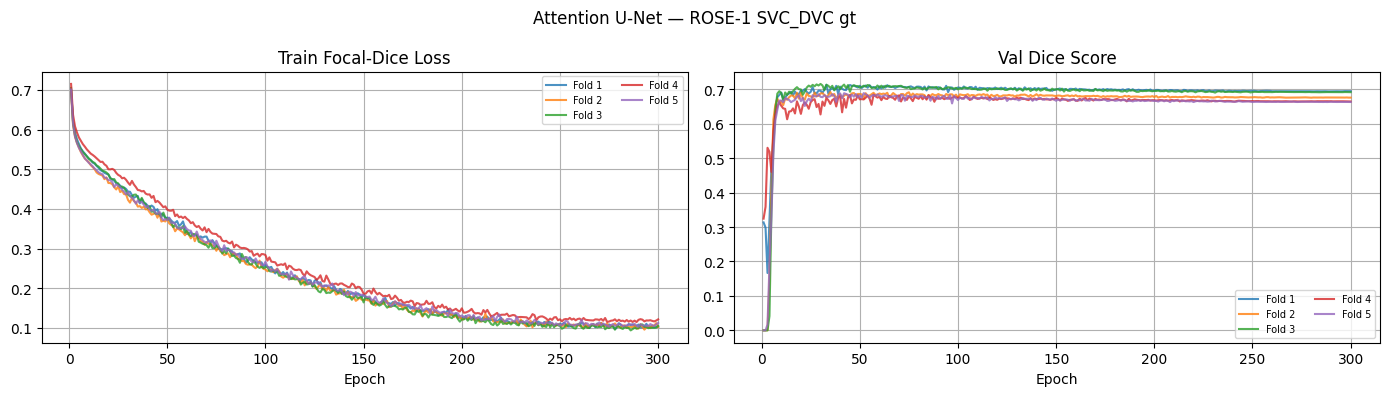

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = plt.cm.tab10.colors

for i, h in enumerate(fold_histories):
    eps = range(1, len(h['train_loss']) + 1)
    c   = colors[i % 10]
    axes[0].plot(eps, h['train_loss'], color=c, lw=1.5, alpha=0.8, label=f'Fold {i+1}')
    axes[1].plot(eps, h['val_dice'],   color=c, lw=1.5, alpha=0.8, label=f'Fold {i+1}')

axes[0].set_title('Train Focal-Dice Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=7, ncol=2);        axes[0].grid(True)
axes[1].set_title('Val Dice Score');        axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=7, ncol=2);        axes[1].grid(True)

plt.suptitle(f'Attention U-Net — ROSE-1 {CATEGORY} {GT_TYPE}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Test-Set Evaluation

Metrics computed per-sample, then aggregated across all folds × test images.


In [10]:
import pandas as pd
from scipy.spatial.distance import directed_hausdorff
from sklearn.metrics import roc_auc_score


def compute_metrics(pred_bin, gt, prob_map=None, s=1e-6):
    """All metrics on flattened numpy arrays."""
    p, g = pred_bin.flatten().astype(float), gt.flatten().astype(float)
    tp = (p * g).sum();          tn = ((1-p) * (1-g)).sum()
    fp = (p * (1-g)).sum();      fn = ((1-p) * g).sum()

    dice  = (2*tp + s) / (2*tp + fp + fn + s)
    jac   = (tp   + s) / (tp   + fp + fn + s)
    sens  = (tp   + s) / (tp   + fn + s)
    spec  = (tn   + s) / (tn   + fp + s)
    prec  = (tp   + s) / (tp   + fp + s) # Precision

    pp, gp = np.argwhere(pred_bin > 0), np.argwhere(gt > 0)
    if len(pp) and len(gp):
        hd = max(directed_hausdorff(pp, gp)[0],
                 directed_hausdorff(gp, pp)[0])
    else:
        hd = float('inf')

    if prob_map is not None and g.sum() > 0 and (1-g).sum() > 0:
        auc = roc_auc_score(g.astype(int), prob_map.flatten())
    else:
        auc = 0.0

    return dict(dice=dice, jaccard=jac, sensitivity=sens, specificity=spec,
                precision=prec, hausdorff=hd, auc=auc)


test_ds     = ROSE1Dataset(BASE_DIR, CATEGORY, 'test',
                            gt_type=GT_TYPE, img_size=IMG_SIZE, augment=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
print(f'Test images: {len(test_ds)}')

all_rows = []
for fold in range(K_FOLDS):
    ckpt = os.path.join(SAVE_DIR, f'best_fold{fold+1}.pth')
    if not os.path.exists(ckpt):
        print(f'  [skip] fold {fold+1} checkpoint not found'); continue
    mdl = UNet().to(device)
    mdl.load_state_dict(torch.load(ckpt, map_location=device))
    mdl.eval()
    with torch.no_grad():
        for i, (imgs, masks) in enumerate(test_loader):
            imgs, masks = imgs.to(device), masks.to(device)
            probs    = mdl(imgs)
            pred_bin = (probs > 0.5).float()
            m = compute_metrics(
                pred_bin[0, 0].cpu().numpy(),
                masks[0, 0].cpu().numpy(),
                probs[0, 0].cpu().numpy())
            m.update(fold=fold+1, sample=i)
            all_rows.append(m)

df = pd.DataFrame(all_rows)
print('\n==== Mean Test Metrics (across all folds & test images) ====')
for col in ['dice', 'jaccard', 'sensitivity', 'specificity', 'precision', 'hausdorff', 'auc']:
    print(f'  {col:12s}: {df[col].mean():.4f} \u00b1 {df[col].std():.4f}')

df.to_csv(os.path.join(SAVE_DIR, 'test_metrics.csv'), index=False)
print(f'\nSaved CSV \u2192 {SAVE_DIR}/test_metrics.csv')


Test images: 9

==== Mean Test Metrics (across all folds & test images) ====
  dice        : 0.7046 ± 0.0483
  jaccard     : 0.5461 ± 0.0595
  sensitivity : 0.6936 ± 0.0753
  specificity : 0.9374 ± 0.0190
  precision   : 0.7213 ± 0.0462
  hausdorff   : 23.8032 ± 4.9737
  auc         : 0.8939 ± 0.0459

Saved CSV → /content/drive/MyDrive/UNet_ROSE1/SVC_DVC_gt/test_metrics.csv


## 9. Visualize Predictions

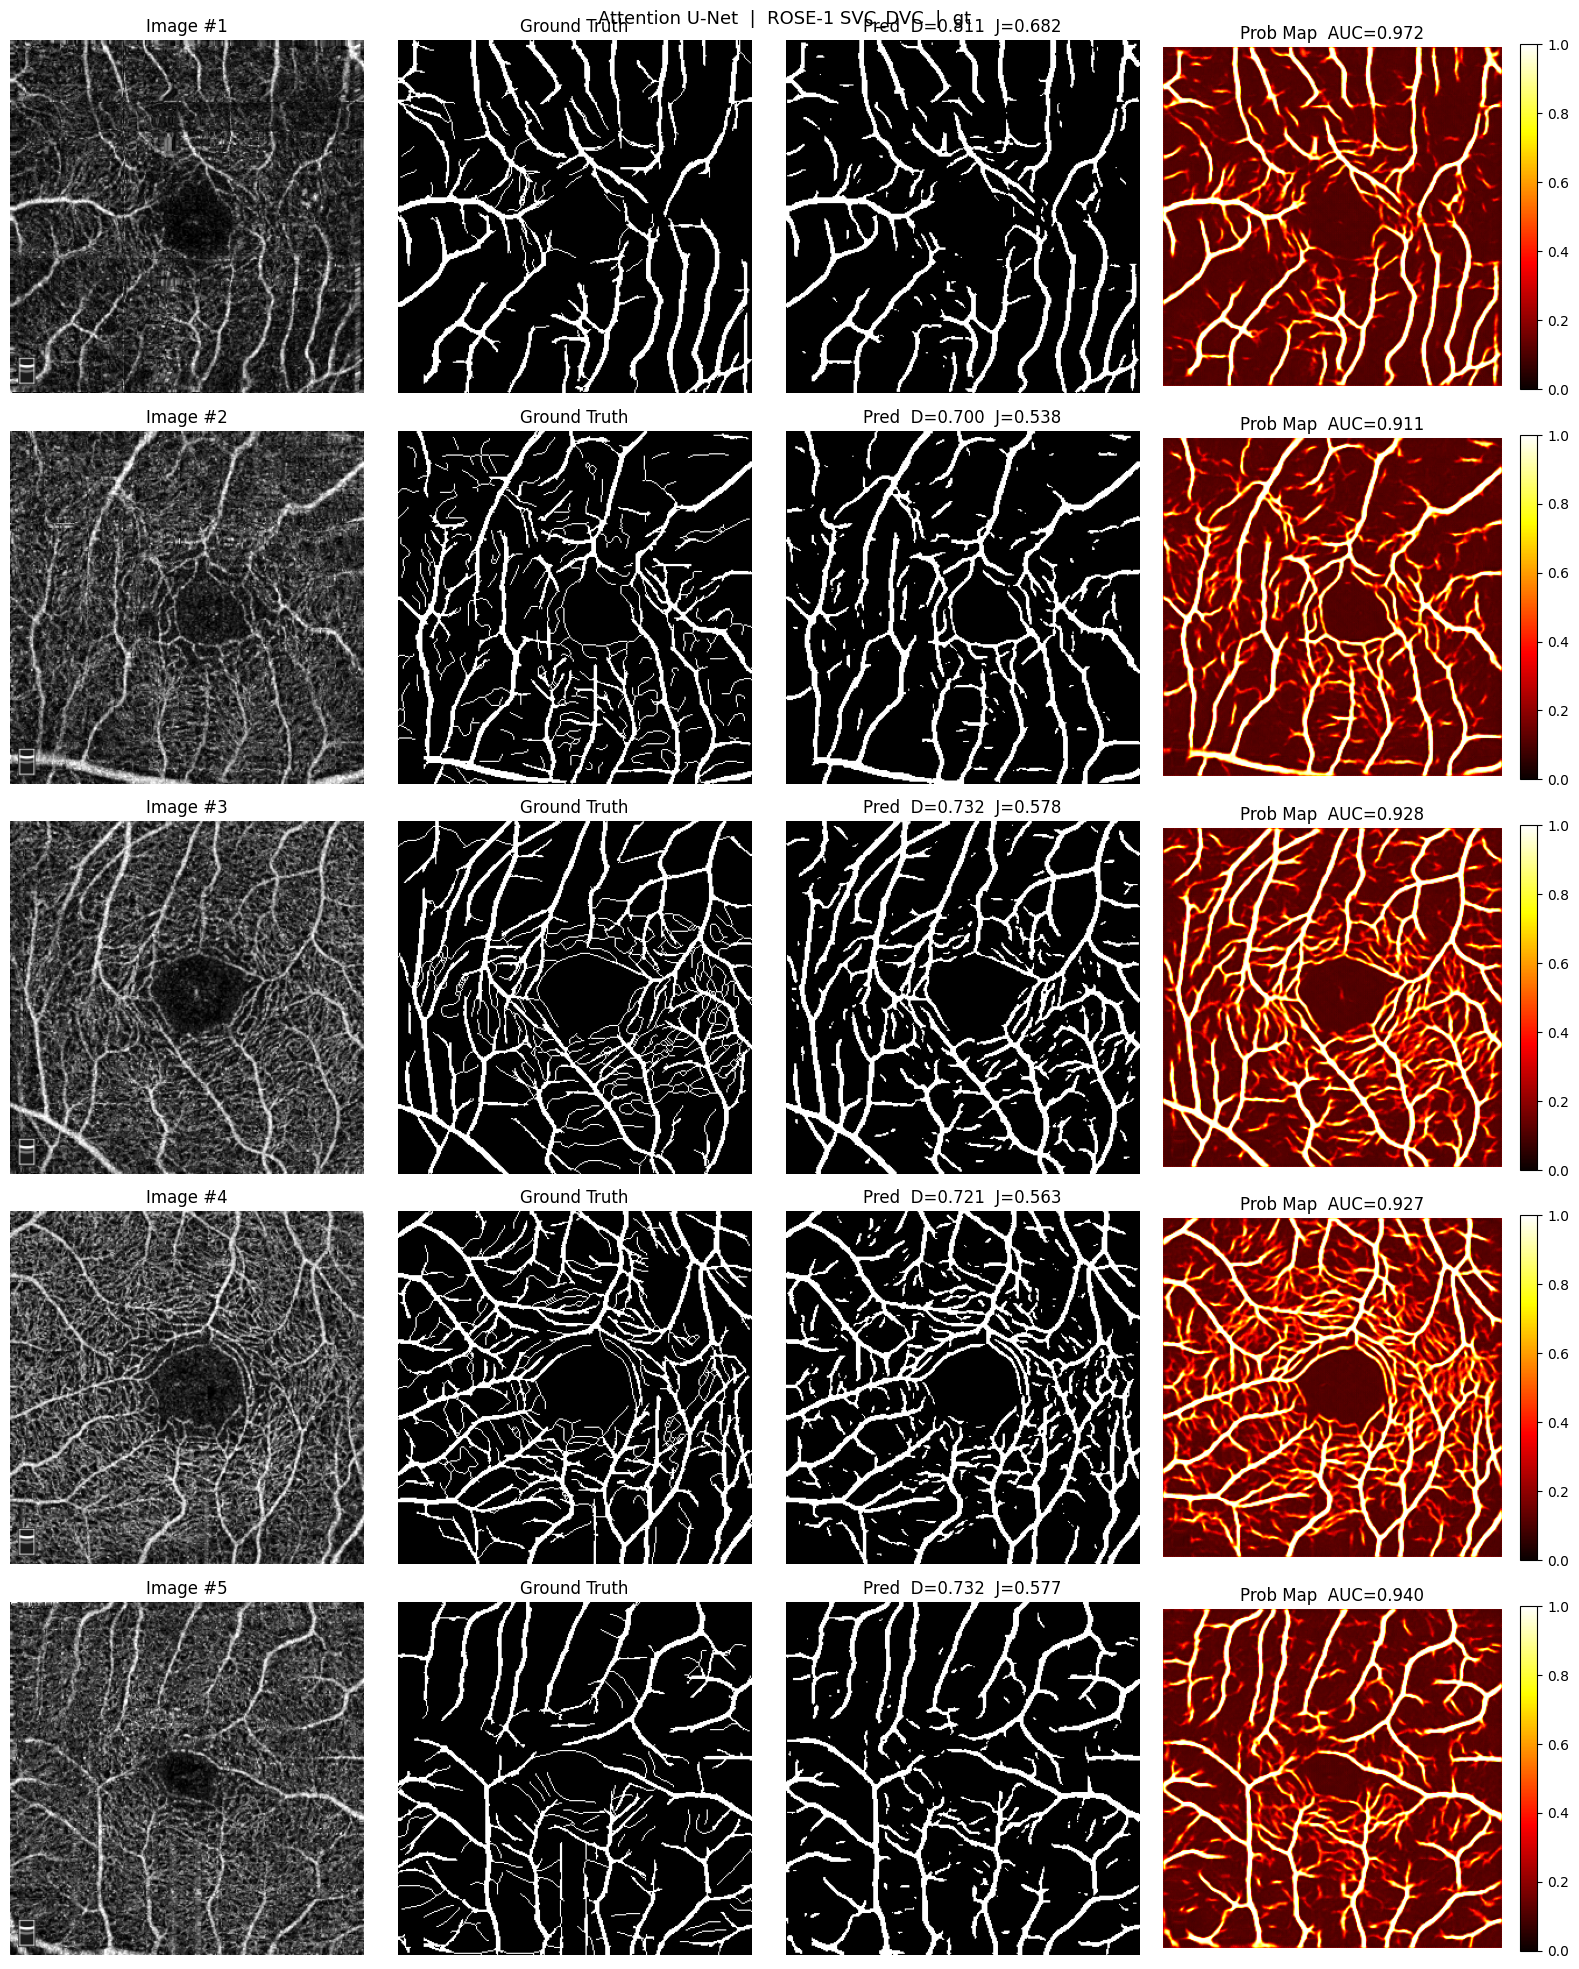

In [11]:
import matplotlib.pyplot as plt

best_model = UNet().to(device)
best_model.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, 'best_overall.pth'), map_location=device))
best_model.eval()

NUM_VIS = min(5, len(test_ds))
fig, axes = plt.subplots(NUM_VIS, 4, figsize=(16, 4 * NUM_VIS))
if NUM_VIS == 1: axes = axes[np.newaxis]
fig.suptitle(f'Attention U-Net  |  ROSE-1 {CATEGORY}  |  {GT_TYPE}', fontsize=13)

with torch.no_grad():
    for i in range(NUM_VIS):
        img, mask = test_ds[i]
        prob = best_model(img.unsqueeze(0).to(device))[0, 0].cpu().numpy()
        pred = (prob > 0.5).astype(float)
        m    = compute_metrics(pred, mask[0].numpy(), prob)

        axes[i, 0].imshow(img[0].numpy(),  cmap='gray')
        axes[i, 0].set_title(f'Image #{i+1}');  axes[i, 0].axis('off')
        axes[i, 1].imshow(mask[0].numpy(), cmap='gray')
        axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title(f'Pred  D={m["dice"]:.3f}  J={m["jaccard"]:.3f}')
        axes[i, 2].axis('off')
        im = axes[i, 3].imshow(prob, cmap='hot', vmin=0, vmax=1)
        axes[i, 3].set_title(f'Prob Map  AUC={m["auc"]:.3f}')
        axes[i, 3].axis('off')
        plt.colorbar(im, ax=axes[i, 3], fraction=0.046)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'predictions.png'), dpi=150, bbox_inches='tight')
plt.show()


## 10. Confusion Matrix, ROC & PR Curves

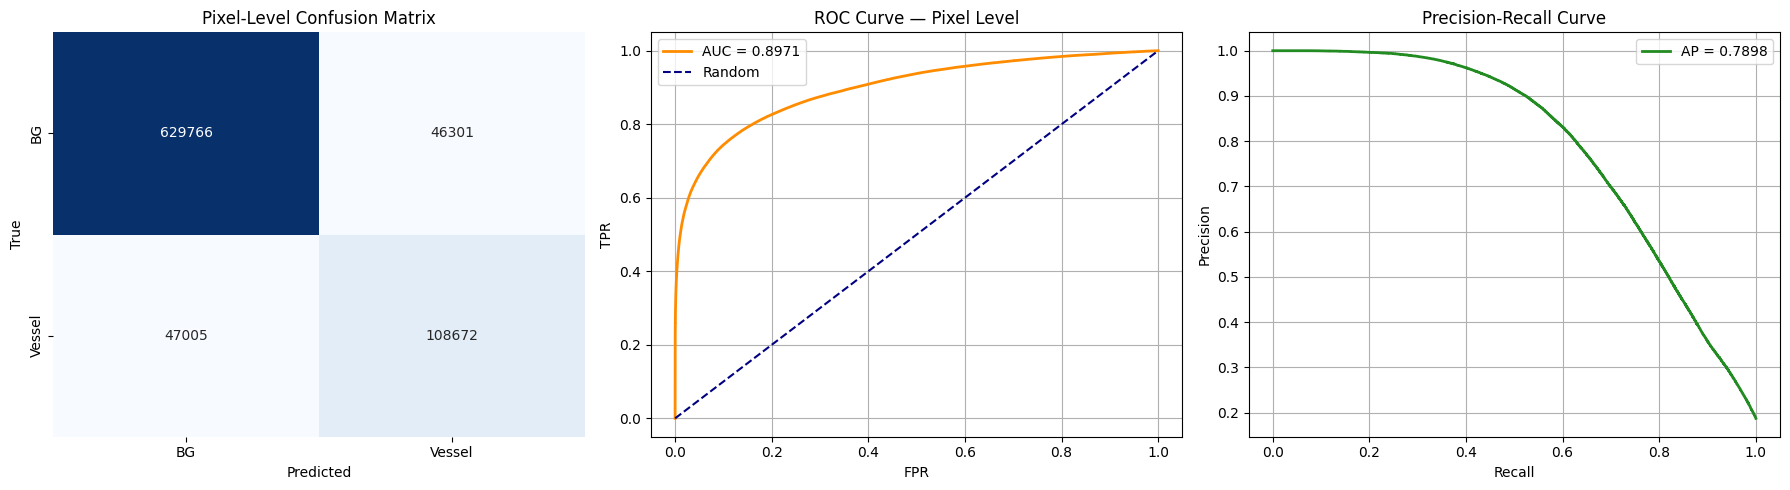

ROC AUC : 0.8971
Avg Prec: 0.7898


In [12]:
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve,
                              auc as sk_auc,
                              precision_recall_curve,
                              average_precision_score)

all_pred, all_gt, all_prob = [], [], []
best_model.eval()
with torch.no_grad():
    for img, mask in test_ds:
        prob = best_model(img.unsqueeze(0).to(device))[0, 0].cpu().numpy()
        pred = (prob > 0.5).astype(int)
        all_pred.append(pred.flatten())
        all_gt.append(mask[0].numpy().flatten().astype(int))
        all_prob.append(prob.flatten())

preds_flat = np.concatenate(all_pred)
gt_flat    = np.concatenate(all_gt)
probs_flat = np.concatenate(all_prob)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(gt_flat, preds_flat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['BG', 'Vessel'],
            yticklabels=['BG', 'Vessel'], cbar=False)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Pixel-Level Confusion Matrix')

# ROC
fpr, tpr, _ = roc_curve(gt_flat, probs_flat)
roc_auc     = sk_auc(fpr, tpr)
axes[1].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'navy', lw=1.5, ls='--', label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Pixel Level')
axes[1].legend(); axes[1].grid(True)

# PR
precision, recall, _ = precision_recall_curve(gt_flat, probs_flat)
ap = average_precision_score(gt_flat, probs_flat)
axes[2].plot(recall, precision, 'forestgreen', lw=2, label=f'AP = {ap:.4f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cm_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC AUC : {roc_auc:.4f}')
print(f'Avg Prec: {ap:.4f}')
